# Group Members:
# Jawad Hassan 2230-0035
# Nimra  2530-4028
# Talha Ramzan 2330-0141
# BS AI
# ANN LAB OPEN ENDED



In [1]:
# 1. Upload your kaggle.json file
from google.colab import files
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# 2. Set up the Kaggle directory and secure the API key
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download the PJM Hourly Energy Consumption dataset
!kaggle datasets download -d robikscube/hourly-energy-consumption

# 4. Unzip the dataset into a specific folder
!unzip -q hourly-energy-consumption.zip -d pjm_energy_data
print("Dataset downloaded and unzipped into the 'pjm_energy_data' directory.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption
License(s): CC0-1.0
100% 11.4M/11.4M [00:01<00:00, 6.28MB/s]

Dataset downloaded and unzipped into the 'pjm_energy_data' directory.


In [2]:
# Task 1: Fetch and Structure Real Grid Data
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Load the continuous hourly dataset
# Using PJME_hourly.csv from the unzipped directory
file_path = 'pjm_energy_data/PJME_hourly.csv'
df = pd.read_csv(file_path)

# Ensure the data is sorted chronologically
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)

# 2. Isolate the energy consumption metric and normalize
# Extracting the target column as a 2D array for the scaler
energy_data = df[['PJME_MW']].values

scaler = MinMaxScaler(feature_range=(0, 1))
energy_scaled = scaler.fit_transform(energy_data)

# 3. Sliding-window function to reshape into a 3D tensor
def create_sequences(data, time_steps):
    X = []
    y = []
    # Loop stops at len(data) - time_steps to ensure there is a target 'y'
    for i in range(len(data) - time_steps):
        X.append(data[i : (i + time_steps)])
        y.append(data[i + time_steps])

    return np.array(X), np.array(y)

time_steps = 12
X, y = create_sequences(energy_scaled, time_steps)

print(f"Full Tensor Shape (X): {X.shape}")
print(f"Target Shape (y): {y.shape}\n")

# 4. Divide into 80% training and 20% testing sets (Sequential Split)
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")

Full Tensor Shape (X): (145354, 12, 1)
Target Shape (y): (145354, 1)

X_train shape: (116283, 12, 1)
y_train shape: (116283, 1)
X_test shape:  (29071, 12, 1)
y_test shape:  (29071, 1)


In [3]:
# Task 2: Build and Train the Dual-Loss Pipeline
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Set a random seed for reproducibility
tf.random.set_seed(42)

# ==========================================
# 1. Baseline Model (MSE Loss)
# ==========================================
print("--- Training Baseline Model (MSE Loss) ---")

baseline_model = Sequential([
    LSTM(32, input_shape=(12, 1)), # time_steps = 12, features = 1
    Dense(1)                       # Linear activation by default
])

baseline_model.compile(optimizer='adam', loss='mse')

history_mse = baseline_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

# ==========================================
# 2. Robust Model (Huber Loss)
# ==========================================
print("\n--- Training Robust Model (Huber Loss) ---")

robust_model = Sequential([
    LSTM(32, input_shape=(12, 1)),
    Dense(1)
])

# Huber loss transitions from quadratic to linear, making it less sensitive
# to massive outliers (like sudden extreme energy spikes) than MSE.
robust_model.compile(optimizer='adam', loss='huber')

history_huber = robust_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)

--- Training Baseline Model (MSE Loss) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - loss: 0.0044 - val_loss: 3.7953e-04
Epoch 2/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 3.7189e-04 - val_loss: 2.0841e-04
Epoch 3/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 2.3403e-04 - val_loss: 1.9272e-04
Epoch 4/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 2.1276e-04 - val_loss: 1.4775e-04
Epoch 5/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 2.0913e-04 - val_loss: 1.3813e-04
Epoch 6/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 2.0520e-04 - val_loss: 1.3887e-04
Epoch 7/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 2.0116e-04 - val_loss: 1.3533e-04
Epoch 8/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 1.9741e-04 - val_loss: 1.3450e-04
Epoch 9/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.9344e-04 - val_loss: 1.3493e-04
Epoch 10/20
1817/1817 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 1.8761e-04 - val_loss: 1.3135e-04
Epoch 11/20
1817/1817 ━━━━━━━━━━━

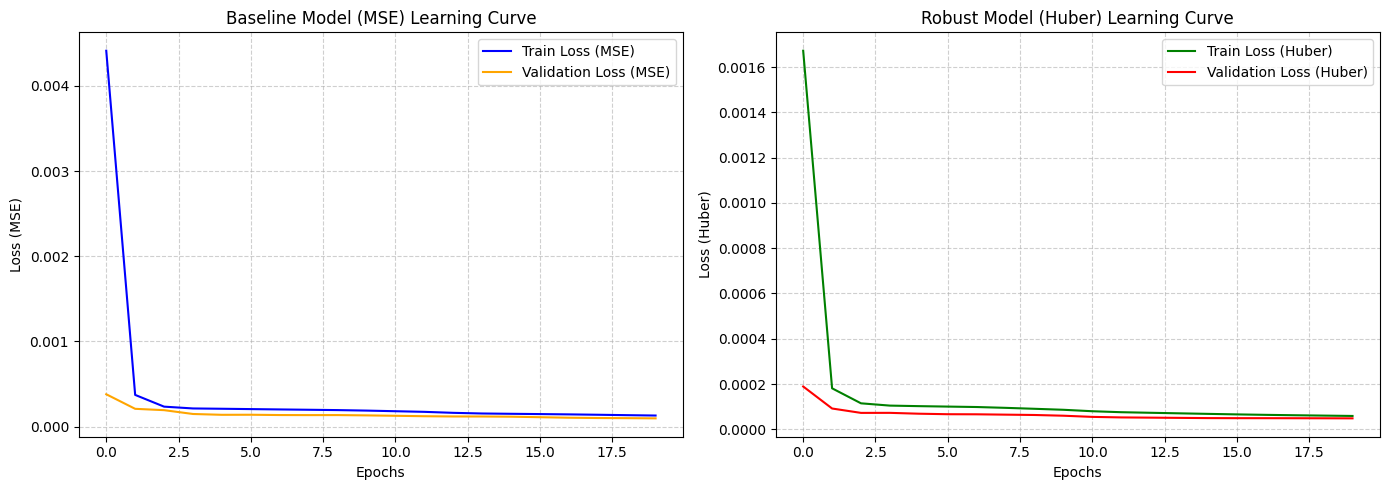

In [4]:
import matplotlib.pyplot as plt

# Create a figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot Baseline Model (MSE) Loss
axes[0].plot(history_mse.history['loss'], label='Train Loss (MSE)', color='blue')
axes[0].plot(history_mse.history['val_loss'], label='Validation Loss (MSE)', color='orange')
axes[0].set_title('Baseline Model (MSE) Learning Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Plot Robust Model (Huber) Loss
axes[1].plot(history_huber.history['loss'], label='Train Loss (Huber)', color='green')
axes[1].plot(history_huber.history['val_loss'], label='Validation Loss (Huber)', color='red')
axes[1].set_title('Robust Model (Huber) Learning Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (Huber)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
--- Final Evaluation Metrics ---
Baseline Model (MSE)   -> MAE: 337.50 MW | MSE: 217683.62
Robust Model (Huber) -> MAE: 340.95 MW | MSE: 218170.95



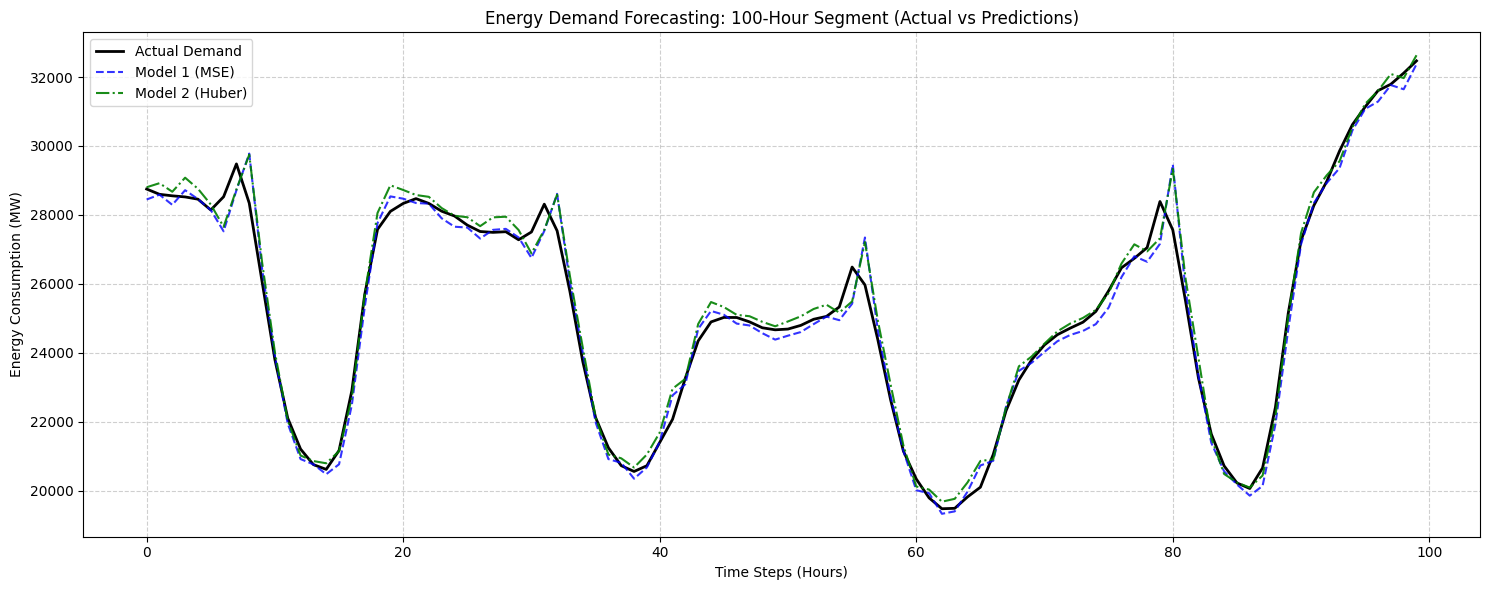

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ==========================================
# 1. Model Inference and Metrics
# ==========================================
# Generate predictions on the test set
pred_mse_scaled = baseline_model.predict(X_test)
pred_huber_scaled = robust_model.predict(X_test)

# Inverse transform to original Megawatt (MW) scale for interpretable metrics
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
pred_mse = scaler.inverse_transform(pred_mse_scaled)
pred_huber = scaler.inverse_transform(pred_huber_scaled)

# Compute MAE and MSE
mae_mse = mean_absolute_error(y_test_inv, pred_mse)
mse_mse = mean_squared_error(y_test_inv, pred_mse)

mae_huber = mean_absolute_error(y_test_inv, pred_huber)
mse_huber = mean_squared_error(y_test_inv, pred_huber)

print("--- Final Evaluation Metrics ---")
print(f"Baseline Model (MSE)   -> MAE: {mae_mse:.2f} MW | MSE: {mse_mse:.2f}")
print(f"Robust Model (Huber) -> MAE: {mae_huber:.2f} MW | MSE: {mse_huber:.2f}\n")

# ==========================================
# 2. 100-Hour Sequence Visualization
# ==========================================
# Select a 100-hour window from the test set (e.g., hours 500 to 600)
start_idx = 500
end_idx = 600

plt.figure(figsize=(15, 6))

# Plot Actual vs. Both Predictions
plt.plot(y_test_inv[start_idx:end_idx], label='Actual Demand', color='black', linewidth=2)
plt.plot(pred_mse[start_idx:end_idx], label='Model 1 (MSE)', color='blue', linestyle='--', alpha=0.8)
plt.plot(pred_huber[start_idx:end_idx], label='Model 2 (Huber)', color='green', linestyle='-.', alpha=0.9)

plt.title('Energy Demand Forecasting: 100-Hour Segment (Actual vs Predictions)')
plt.xlabel('Time Steps (Hours)')
plt.ylabel('Energy Consumption (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

#Summary:
Looking closely at hour 80, the actual energy demand experiences a sharp, sudden peak, which the Baseline MSE model (blue line) aggressively over-predicts by shooting up past 29,000 MW. Because Mean Squared Error exponentially penalizes large deviations, it forces the model to heavily distort its predictions to "catch" what it perceives as massive errors during sudden, volatile shifts. The Huber loss function, however, transitions to a linear penalty for extreme outliers, mathematically limiting the gravitational pull of these sudden spikes on the network. Consequently, the Robust Huber model (green line) maintained a more reliable and conservative trend line through this volatility, resisting the severe over-correction seen in the MSE model.